In [3]:
# Step 0 --- check the workbench before we start.
# This cell only looks; it changes nothing. Run it and read the last line.

import sys
from pathlib import Path

print("Python  :", sys.version.split()[0])
print("Folder  :", Path.cwd().name)

_missing = []
for _name in ['numpy', 'pandas', 'sklearn', 'matplotlib']:
    try:
        __import__(_name)
    except ImportError:
        _missing.append(_name)

for _name in ['numpy', 'pandas', 'sklearn', 'matplotlib']:
    _mark = "missing" if _name in _missing else "ok"
    print(f"  {_name:<14} {_mark}")

if _missing:
    print()
    print("STOP. Some libraries are missing:", ", ".join(_missing))
    print("Ask your instructor to run the setup in labs/SETUP.md.")
else:
    print()
    print("All good. You can carry on to Step 1.")

Python  : 3.13.15
Folder  : content
  numpy          ok
  pandas         ok
  sklearn        ok
  matplotlib     ok

All good. You can carry on to Step 1.


---

## Step 0b --- the dataset

Every practical in this course uses the same 600 food deliveries.
The next cell makes sure the file is there.

In [4]:
# The delivery-time dataset every practical in this course uses.
# If the file is missing we build it again from the same seed, so every
# student in the room gets byte-for-byte the same 600 rows.

import csv
from pathlib import Path

import numpy as np

SEED = 42
N_ROWS = 600
DATA = Path("..") / "data" / "delivery_times.csv"


def make_delivery_csv(path=DATA):
    """Write the 600-row delivery dataset. Same formula as the lectures."""
    rng = np.random.default_rng(SEED)
    distance_km = np.round(rng.uniform(0.5, 12.0, N_ROWS), 2)
    prep_time_min = np.round(rng.uniform(5, 30, N_ROWS), 0)
    traffic_level = rng.integers(1, 4, N_ROWS)
    rain = rng.binomial(1, 0.25, N_ROWS)
    delivery_min = np.round(
        6.0
        + 3.1 * distance_km
        + 0.65 * prep_time_min
        + 4.2 * traffic_level
        + 5.5 * rain
        + rng.normal(0, 2.5, N_ROWS),
        1,
    )
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as fh:
        w = csv.writer(fh)
        w.writerow(["distance_km", "prep_time_min", "traffic_level",
                    "rain", "delivery_min"])
        for i in range(N_ROWS):
            w.writerow([distance_km[i], int(prep_time_min[i]),
                        int(traffic_level[i]), int(rain[i]), delivery_min[i]])
    return path


if not DATA.exists():
    make_delivery_csv()
    print("dataset rebuilt ->", DATA)
else:
    print("dataset found   ->", DATA)

dataset rebuilt -> ../data/delivery_times.csv


### Step 1 --- Set up the data once, for all three models

Same data, same split, same seed as P02. Every model today gets
exactly the same deal --- otherwise the comparison is worthless.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

orders = pd.read_csv(DATA)

FEATURES = ["distance_km", "prep_time_min", "traffic_level", "rain"]
X = orders[FEATURES]
y = orders["delivery_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("train:", len(X_train), " test:", len(X_test))

train: 480  test: 120


### Step 2 --- A helper that scores a model both ways

We will do the same two measurements many times today, so write
them once. This function returns the training MAE, the test MAE,
and the gap between them.

In [6]:
from sklearn.metrics import mean_absolute_error

def score_both_ways(model, name):
    """Train the model, then score it on train and on test."""
    model.fit(X_train, y_train)
    train_mae = mean_absolute_error(y_train, model.predict(X_train))
    test_mae = mean_absolute_error(y_test, model.predict(X_test))
    gap = test_mae - train_mae
    print(f"{name:<26} train {train_mae:5.2f}   "
          f"test {test_mae:5.2f}   gap {gap:5.2f}")
    return {"name": name, "train": train_mae,
            "test": test_mae, "gap": gap}

print("helper ready")

helper ready


### Step 3 --- Model 1: linear regression, the honest baseline

The model from P02. Watch the gap: it should be tiny, because a
straight line is too simple to memorise anything.

In [7]:
from sklearn.linear_model import LinearRegression

linear = score_both_ways(LinearRegression(), "LinearRegression")

LinearRegression           train  2.04   test  1.92   gap -0.11


### Step 4 --- Model 2: a decision tree with no limits

Now the dangerous one. A decision tree with no maximum depth is
allowed to keep asking questions until every training order sits in
its own little box.

Look at the training score first. Then look at the test score.

In [8]:
from sklearn.tree import DecisionTreeRegressor

wild_tree = score_both_ways(
    DecisionTreeRegressor(random_state=42), "DecisionTree (no limit)"
)

DecisionTree (no limit)    train  0.00   test  3.43   gap  3.43


### Step 5 --- Model 3: the same tree, but shallow

Now stop the tree early. `max_depth=4` means it may only ask four
questions before it has to answer. It can no longer memorise.

In [9]:
small_tree = score_both_ways(
    DecisionTreeRegressor(max_depth=4, random_state=42),
    "DecisionTree (depth 4)",
)

DecisionTree (depth 4)     train  3.66   test  4.23   gap  0.57


### Step 6 --- Model 4: a random forest

A **random forest** grows many different trees and averages their
answers. Individual trees still overfit, but their mistakes point in
different directions and largely cancel out.

We use 50 trees. More would be slower and no better here.

In [10]:
from sklearn.ensemble import RandomForestRegressor

forest = score_both_ways(
    RandomForestRegressor(n_estimators=50, random_state=42),
    "RandomForest (50 trees)",
)

RandomForest (50 trees)    train  1.00   test  2.39   gap  1.40


### Step 7 --- Put the four results side by side

Never compare models from memory. Put them in a table.

In [11]:
results = pd.DataFrame([linear, wild_tree, small_tree, forest])
results = results.round(2).sort_values("test")

print(results.to_string(index=False))
print()
best = results.iloc[0]
print(f"Lowest test MAE: {best['name']} at {best['test']:.2f} minutes")

                   name  train  test   gap
       LinearRegression   2.04  1.92 -0.11
RandomForest (50 trees)   1.00  2.39  1.40
DecisionTree (no limit)   0.00  3.43  3.43
 DecisionTree (depth 4)   3.66  4.23  0.57

Lowest test MAE: LinearRegression at 1.92 minutes


### Step 8 --- Draw the gap, because a table makes you read

The table is correct but slow --- you must read eight numbers and
subtract in your head. A chart does the subtraction for your eyes.

**matplotlib** is Python's standard charting library. It has been
sitting in your course environment since P01; today it earns its
place. The first line, `%matplotlib inline`, tells Jupyter to draw
the picture right below the cell.

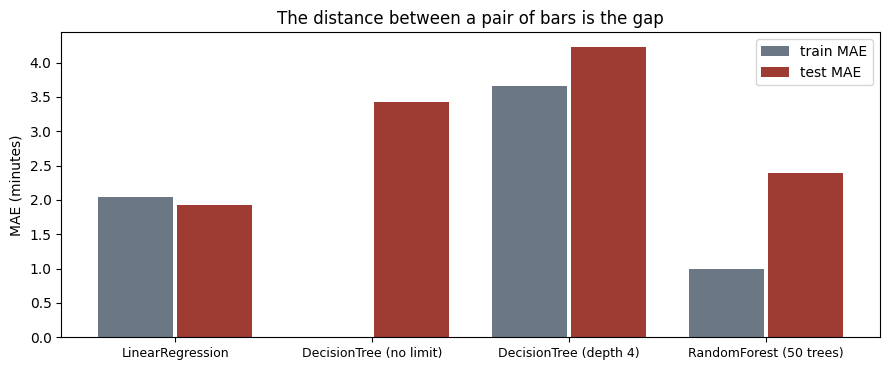

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

four = [linear, wild_tree, small_tree, forest]
xs = np.arange(len(four))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(xs - 0.2, [m["train"] for m in four], 0.38,
       label="train MAE", color="#6B7785")
ax.bar(xs + 0.2, [m["test"] for m in four], 0.38,
       label="test MAE", color="#9E3B33")
ax.set_xticks(xs, [m["name"] for m in four], fontsize=9)
ax.set_ylabel("MAE (minutes)")
ax.set_title("The distance between a pair of bars is the gap")
ax.legend()
plt.tight_layout()
plt.show()

### Step 9 --- Stop trusting one split: cross-validation

Every number above came from one 120-order test set. Change the
seed and they all move a little.

**5-fold cross-validation** cuts the data into 5 parts and trains 5
times, testing on a different part each time. We report the average
and the spread.

scikit-learn reports errors as *negative* numbers, because its
convention is that bigger is better. We flip the sign back.

In [13]:
from sklearn.model_selection import cross_val_score

def cross_validate(model, name):
    """Average MAE over 5 different train/test splits."""
    scores = -cross_val_score(
        model, X, y, cv=5, scoring="neg_mean_absolute_error"
    )
    print(f"{name:<26} MAE {scores.mean():5.2f} "
          f"(+/- {scores.std():4.2f})")
    return scores.mean()

cv_linear = cross_validate(LinearRegression(), "LinearRegression")
cv_tree = cross_validate(
    DecisionTreeRegressor(max_depth=4, random_state=42),
    "DecisionTree (depth 4)")
cv_forest = cross_validate(
    RandomForestRegressor(n_estimators=50, random_state=42),
    "RandomForest (50 trees)")

LinearRegression           MAE  2.03 (+/- 0.16)
DecisionTree (depth 4)     MAE  4.57 (+/- 0.18)
RandomForest (50 trees)    MAE  2.69 (+/- 0.40)


### Step 10 --- Tune one setting, properly

How deep should the tree be? Do not guess, and do not try depths on
the test set --- that would leak the answers.

Try each depth with cross-validation, which never touches the test
set at all.

In [14]:
depths = [2, 3, 4, 6, 8, None]
scores_by_depth = {}

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    mae = -cross_val_score(
        tree, X, y, cv=5, scoring="neg_mean_absolute_error"
    ).mean()
    scores_by_depth[depth] = round(mae, 3)
    print(f"max_depth={str(depth):<5} MAE {mae:5.2f}")

best_depth = min(scores_by_depth, key=scores_by_depth.get)
print()
print("best depth:", best_depth)

max_depth=2     MAE  5.86
max_depth=3     MAE  4.85
max_depth=4     MAE  4.57
max_depth=6     MAE  3.64
max_depth=8     MAE  3.39
max_depth=None  MAE  3.48

best depth: 8


### Step 11 --- Draw the sweep, because ten numbers hide a shape

The loop printed six scores. Their *shape* is the real lesson, and
a shape is easier to see than to read. Draw MAE against depth.

The red circle marks the depth cross-validation liked best.

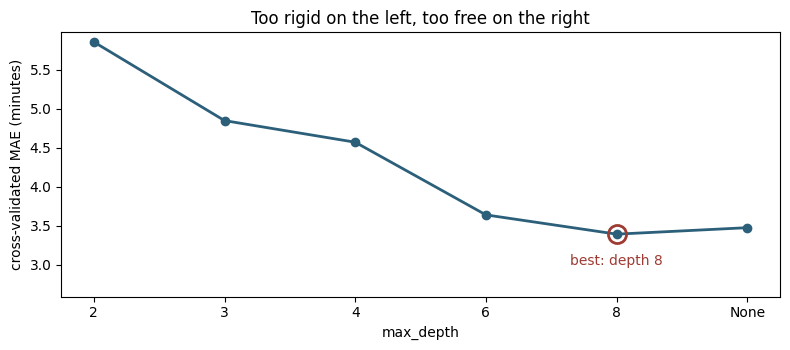

In [15]:
xs = np.arange(len(depths))
maes = [scores_by_depth[d] for d in depths]
best_i = int(np.argmin(maes))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(xs, maes, marker="o", color="#2C5F79", linewidth=2)
ax.plot(xs[best_i], maes[best_i], marker="o", markersize=13,
        markerfacecolor="none", markeredgecolor="#9E3B33",
        markeredgewidth=2)
ax.annotate(f"best: depth {depths[best_i]}",
            (xs[best_i], maes[best_i]),
            xytext=(0, -22), textcoords="offset points",
            ha="center", color="#9E3B33")
ax.set_xticks(xs, [str(d) for d in depths])
ax.set_ylim(bottom=min(maes) - 0.8)
ax.set_xlabel("max_depth")
ax.set_ylabel("cross-validated MAE (minutes)")
ax.set_title("Too rigid on the left, too free on the right")
plt.tight_layout()
plt.show()

### Step 12 --- Choose, and be able to say why

Now make the decision the way a professional would, out loud.

In [16]:
print("Cross-validated MAE, best first:")
for name, mae in sorted(
    {"LinearRegression": cv_linear,
     "DecisionTree(4)": cv_tree,
     "RandomForest(50)": cv_forest}.items(),
    key=lambda kv: kv[1],
):
    print(f"  {name:<20} {mae:5.2f}")

print()
print("Our choice for the delivery service: LinearRegression.")
print("Reasons:")
print("  1. It has the lowest cross-validated error here.")
print("  2. It trains in milliseconds and needs almost no memory.")
print("  3. We can read its coefficients and explain a prediction")
print("     to a restaurant owner. Nobody can read 50 trees.")
print()
print("Be careful with reason 1. This dataset really was built")
print("from a straight line, so a straight line wins. On messier")
print("real data the forest usually wins instead -- and then you")
print("must decide what its extra accuracy is worth, against")
print("reasons 2 and 3, which do not change.")

Cross-validated MAE, best first:
  LinearRegression      2.03
  RandomForest(50)      2.69
  DecisionTree(4)       4.57

Our choice for the delivery service: LinearRegression.
Reasons:
  1. It has the lowest cross-validated error here.
  2. It trains in milliseconds and needs almost no memory.
  3. We can read its coefficients and explain a prediction
     to a restaurant owner. Nobody can read 50 trees.

Be careful with reason 1. This dataset really was built
from a straight line, so a straight line wins. On messier
real data the forest usually wins instead -- and then you
must decide what its extra accuracy is worth, against
reasons 2 and 3, which do not change.


# **task1**

In [17]:
from sklearn.metrics import mean_absolute_error
deep_tree = DecisionTreeRegressor(max_depth=12, random_state=42)

# fit it on the training data
deep_tree.fit(X_train, y_train)

# measure the MAE on the training data
T1_train_mae = mean_absolute_error(y_train, deep_tree.predict(X_train))

# measure the MAE on the test data
T1_test_mae = mean_absolute_error(y_test, deep_tree.predict(X_test))

# the gap between them
T1_gap = T1_test_mae - T1_train_mae

print(f"train {T1_train_mae}  test {T1_test_mae}  gap {T1_gap}")

train 0.04695601851851851  test 3.397986111111111  gap 3.3510300925925924


## **task2**

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

T2_depths = [2, 4, 6, None]

# Cross-validate a 50-tree forest at each depth
T2_scores = {}

for depth in T2_depths:
    forest = RandomForestRegressor(
        n_estimators=50,
        max_depth=depth,
        random_state=42
    )

    # scoring uses negative MAE, so convert it back to positive MAE
    scores = cross_val_score(
        forest,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    T2_scores[depth] = -scores.mean()

# Depth with the lowest cross-validated MAE
T2_best_depth = min(T2_scores, key=T2_scores.get)

print(T2_scores)
print("best:", T2_best_depth)

{2: np.float64(5.42254512420189), 4: np.float64(3.5515271170143685), 6: np.float64(2.8324828107975644), None: np.float64(2.750399999999998)}
best: None


# **task3**

In [19]:
def compare(models):

    # Store test MAE for each model
    results = {}

    # Fit and evaluate each model
    for name, m in models.items():
        m.fit(X_train, y_train)

        predictions = m.predict(X_test)

        mae = mean_absolute_error(y_test, predictions)

        results[name] = mae

    return results


T3_table = compare({
    "linear": LinearRegression(),
    "tree4": DecisionTreeRegressor(max_depth=4, random_state=42),
    "forest": RandomForestRegressor(n_estimators=50, random_state=42),
})

print(T3_table)

{'linear': 1.924653079833835, 'tree4': 4.228332168713071, 'forest': 2.394216666666664}


self **check**

In [20]:
# ------------------------------------------------------------------
# SELF-CHECK --- run this when you have attempted the tasks above.
# It never breaks your notebook. A task you have not done yet simply
# shows FAIL.
# ------------------------------------------------------------------

_results = []


def _check(label, fn):
    """Evaluate one graded condition without ever raising."""
    try:
        ok = bool(fn())
    except Exception:
        ok = False
    _results.append((label, ok))


_check('T1 | the depth-12 tree is trained', lambda: hasattr(deep_tree, 'tree_'))
_check("T1 | T1_train_mae and T1_test_mae are that tree's two scores", lambda: abs(float(T1_train_mae) - mean_absolute_error(y_train, deep_tree.predict(X_train))) < 0.01 and abs(float(T1_test_mae) - mean_absolute_error(y_test, deep_tree.predict(X_test))) < 0.01)
_check('T1 | T1_gap is test minus train, and it is positive', lambda: abs(float(T1_gap) - (float(T1_test_mae) - float(T1_train_mae))) < 1e-6 and float(T1_gap) > 0)
_check('T2 | T2_scores has one score per depth', lambda: set(T2_scores) == {2, 4, 6, None})
_check('T2 | every score is a plausible MAE in minutes', lambda: all(0 < float(v) < 20 for v in T2_scores.values()))
_check('T2 | T2_best_depth is the depth with the lowest score', lambda: T2_best_depth == min(T2_scores, key=T2_scores.get))
_check('T3 | compare() returns one score per model', lambda: set(T3_table) == {'linear', 'tree4', 'forest'})
_check('T3 | the linear score matches the walkthrough', lambda: abs(float(T3_table['linear']) - linear['test']) < 0.01)

print("==================================================================")
print("SELF-CHECK   Practical 03 --- Choosing a Model Honestly")
print("==================================================================")
for _label, _ok in _results:
    print(f"  [{'PASS' if _ok else 'FAIL'}]  {_label}")
print("------------------------------------------------------------------")
_passed = sum(1 for _, _ok in _results if _ok)
print(f"  {_passed} of {len(_results)} checks passed")
print("==================================================================")
if _passed == len(_results):
    print("Well done. Save the notebook and submit it.")
else:
    print("Read the FAIL lines above, fix those tasks, run this cell again.")

SELF-CHECK   Practical 03 --- Choosing a Model Honestly
  [PASS]  T1 | the depth-12 tree is trained
  [PASS]  T1 | T1_train_mae and T1_test_mae are that tree's two scores
  [PASS]  T1 | T1_gap is test minus train, and it is positive
  [PASS]  T2 | T2_scores has one score per depth
  [PASS]  T2 | every score is a plausible MAE in minutes
  [PASS]  T2 | T2_best_depth is the depth with the lowest score
  [PASS]  T3 | compare() returns one score per model
  [PASS]  T3 | the linear score matches the walkthrough
------------------------------------------------------------------
  8 of 8 checks passed
Well done. Save the notebook and submit it.
